In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


# Housing price segmentation

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load data
data = pd.read_csv(r"C:\Users\79308\Desktop\patel\Cluster\6 House price\archive (6)/House Price India.csv")

# Data cleaning
data = data.drop(["Date"], axis=1)
data["number of bedrooms"] = data["number of bedrooms"].astype(int)
data["waterfront present"] = data["waterfront present"].astype(int)

# Feature Engineering: Age of the house
data["house_age"] = data["Built Year"].max() - data["Built Year"]

# 1. Visualisation

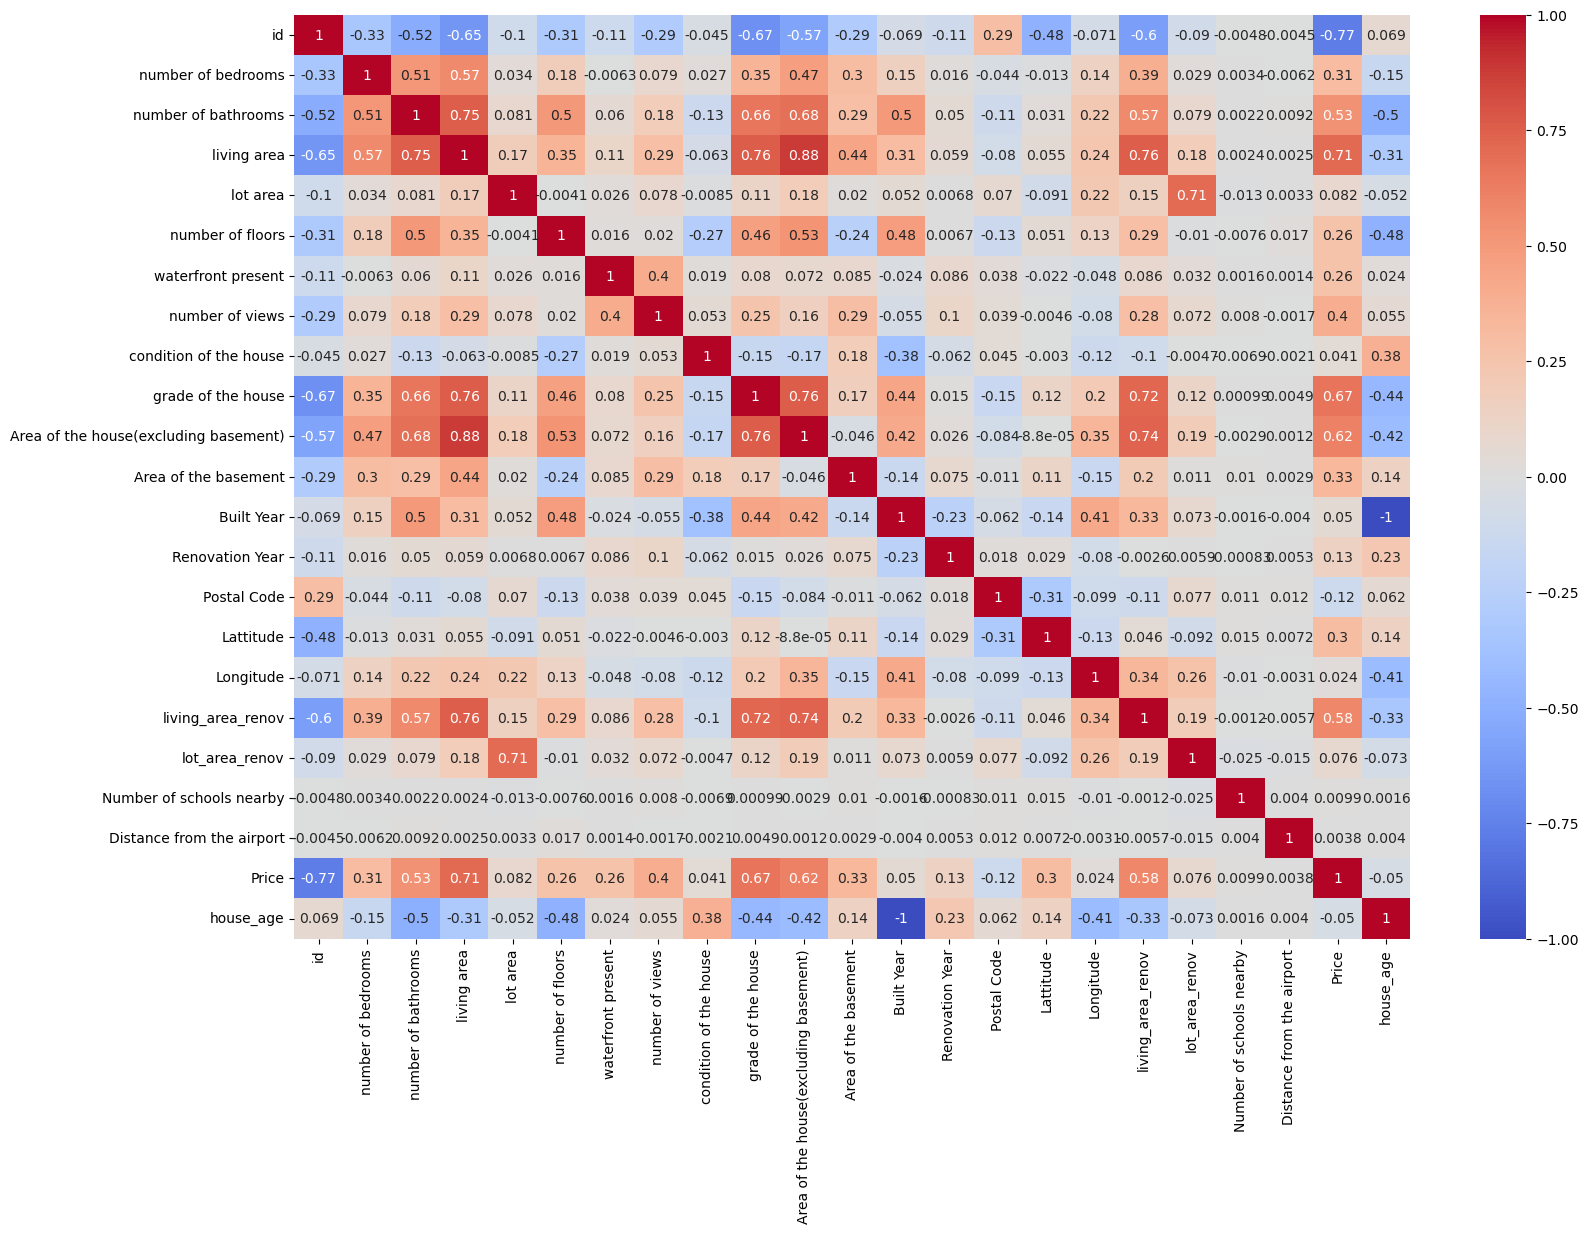

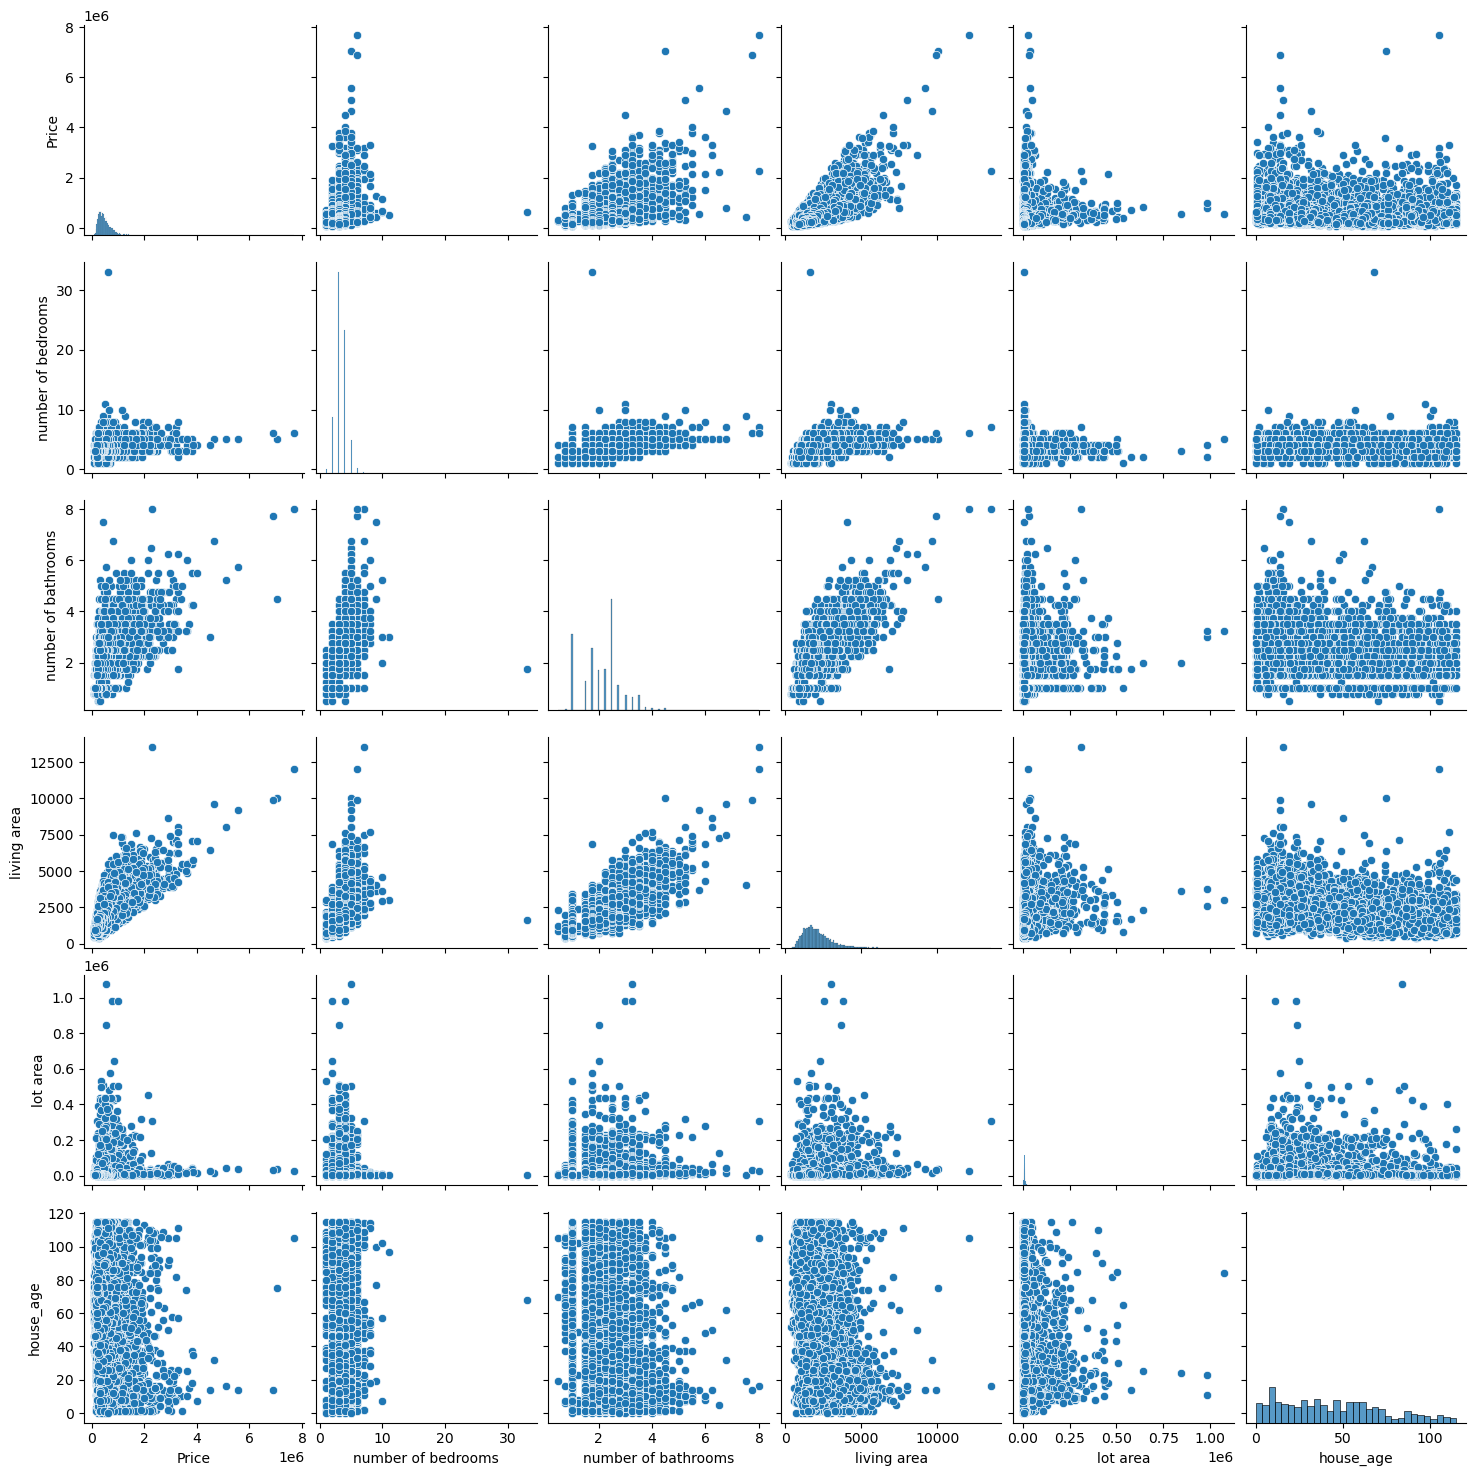

In [12]:
# Correlation heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

# Pairplot for selected features
selected_features = ["Price", "number of bedrooms", "number of bathrooms", "living area", "lot area", "house_age"]
sns.pairplot(data[selected_features])
plt.show()



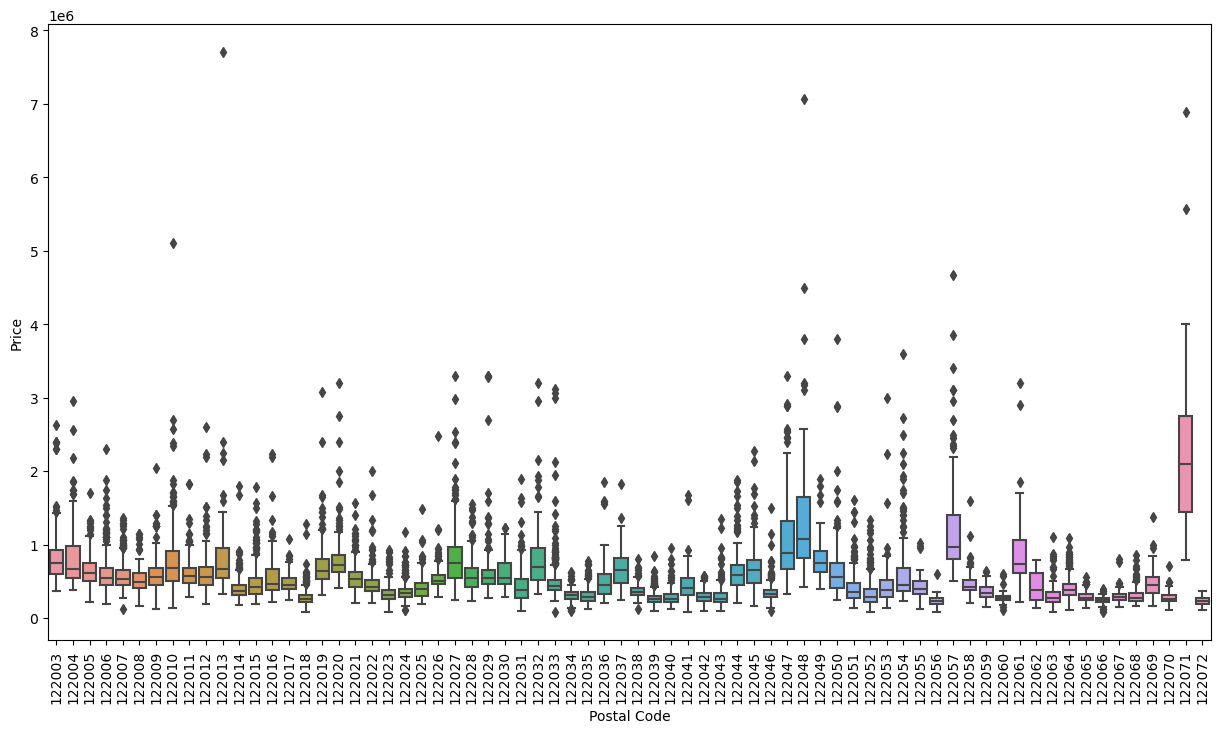

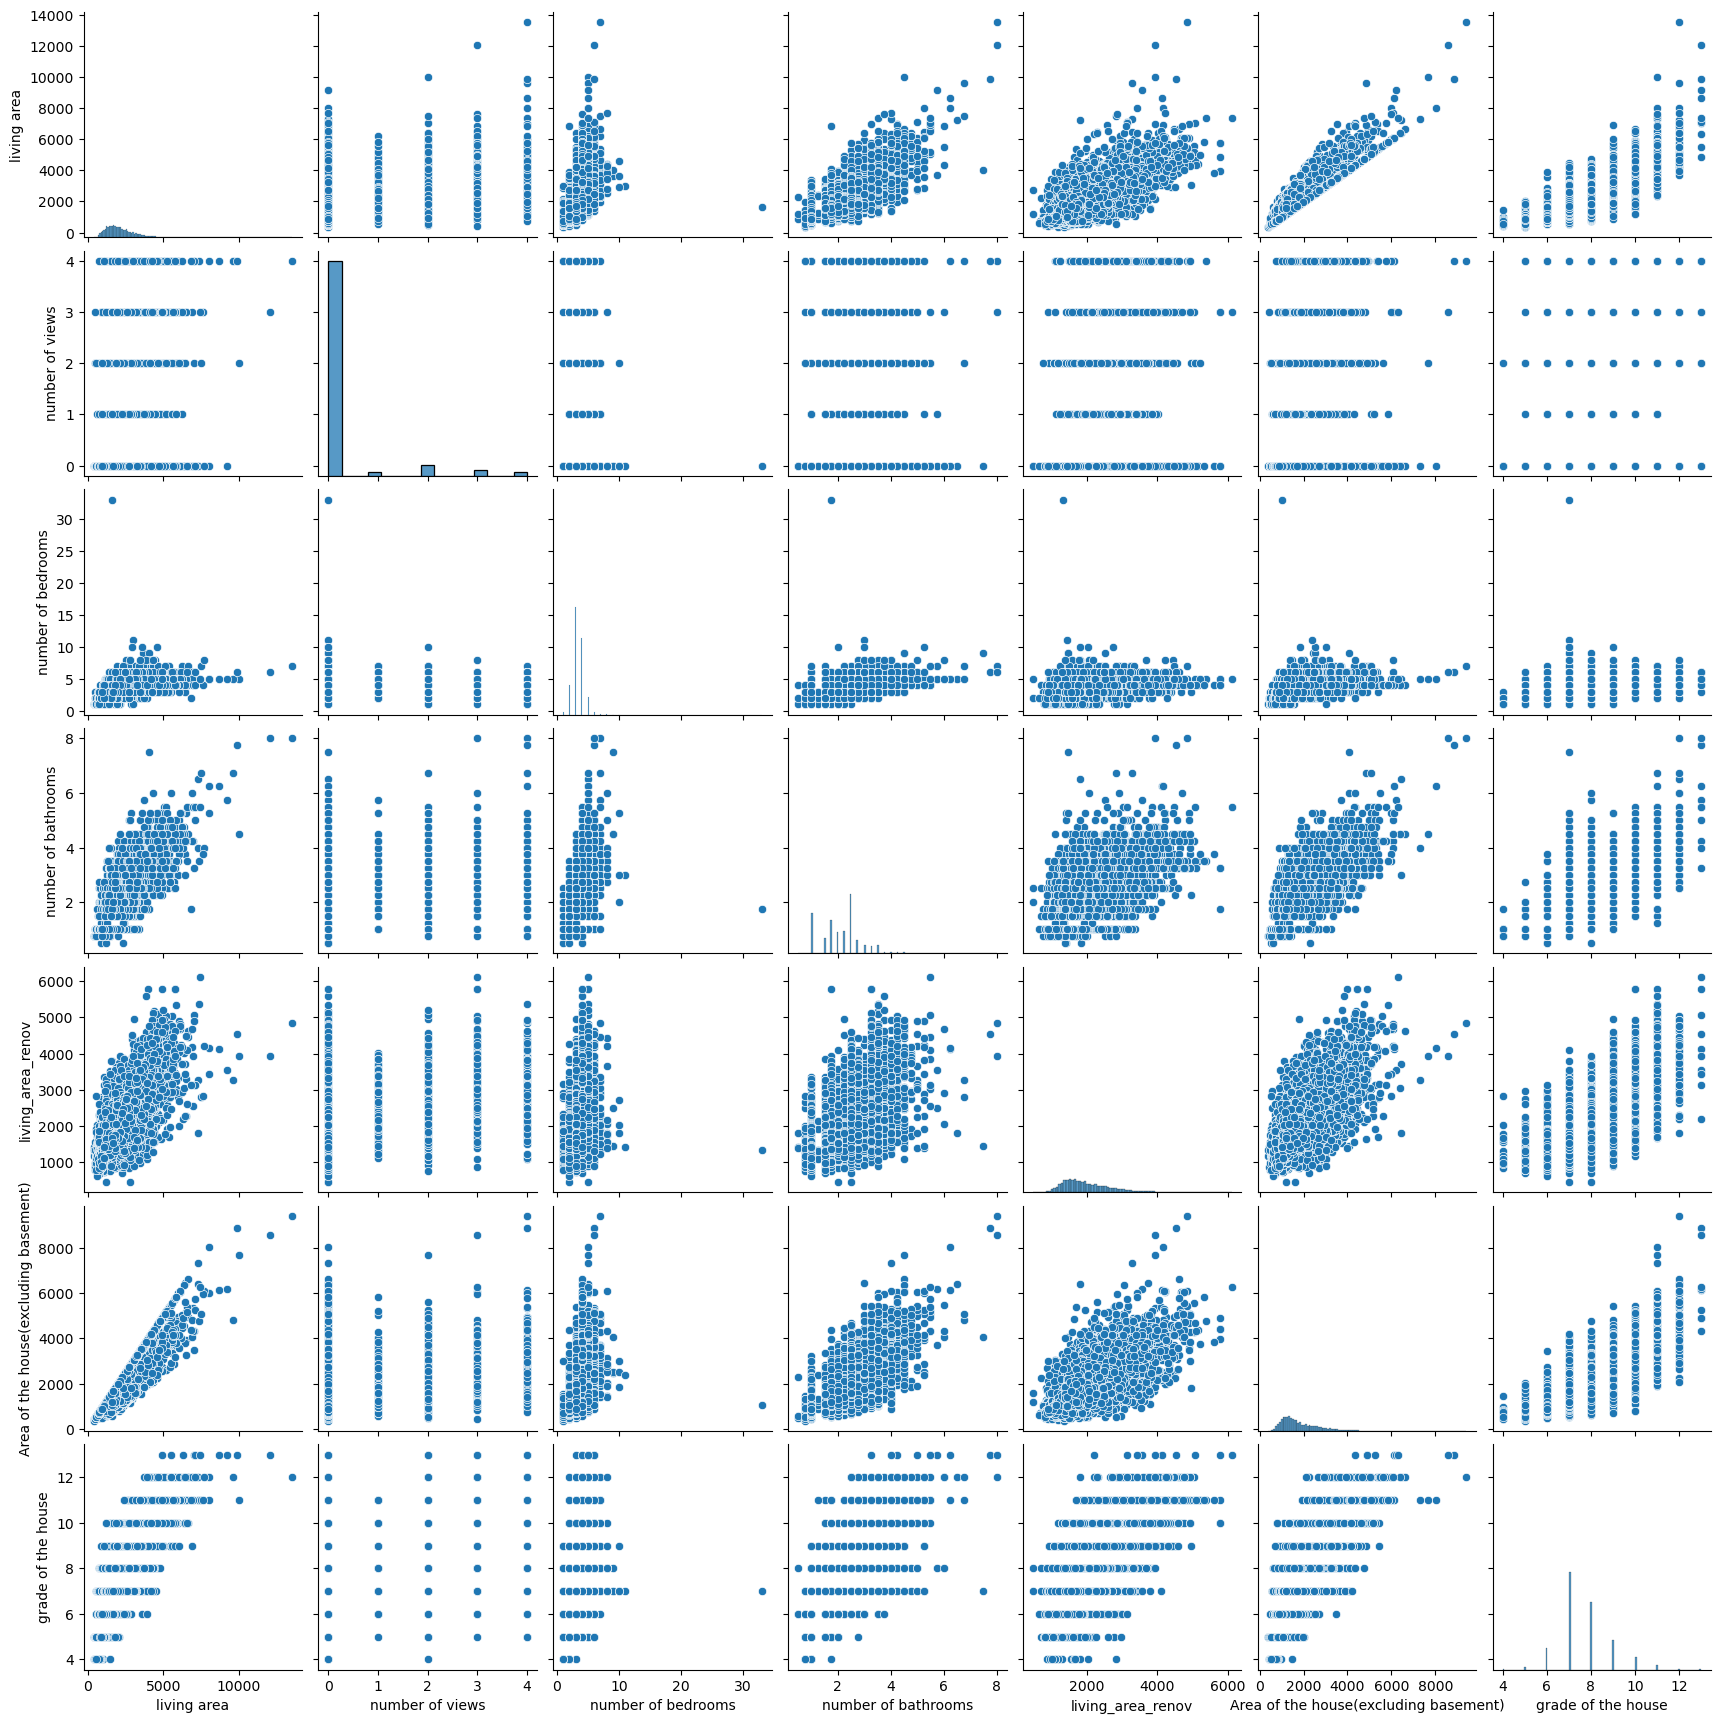

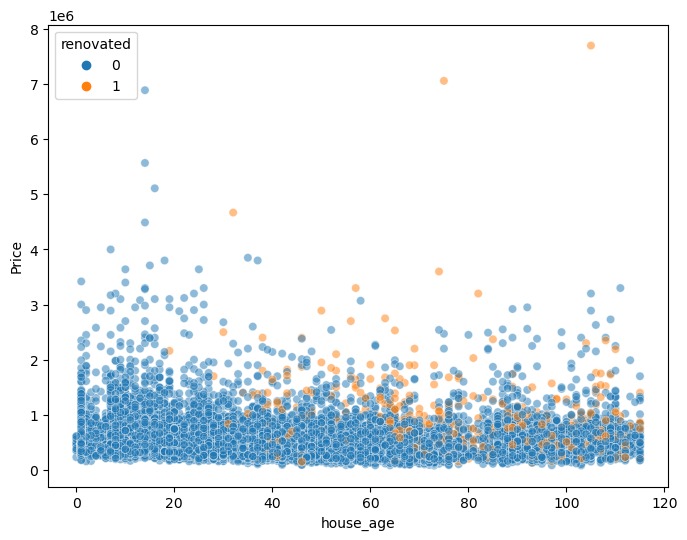

In [13]:
# 1. House prices across postal codes:

plt.figure(figsize=(15, 8))
sns.boxplot(x="Postal Code", y="Price", data=data)
plt.xticks(rotation=90)
plt.show()

#2. Relationship between house size and other features:

# Scatterplot matrix
size_features = ["living area", "number of views", "number of bedrooms", "number of bathrooms", "living_area_renov", "Area of the house(excluding basement)", "grade of the house"]
sns.pairplot(data[size_features])
plt.show()

#3. Age and renovation year's effect on house prices:

# Create a new column for renovation status
data["renovated"] = data["Renovation Year"].apply(lambda x: 1 if x > 0 else 0)

# Scatterplot for age and price
plt.figure(figsize=(8, 6))
sns.scatterplot(x="house_age", y="Price", hue="renovated", data=data, alpha=0.5)
plt.show()

# 2. Clustering

---
## Step 1 & 2: Clustering Pipeline (PyCaret)

Automated clustering pipeline with PyCaret:
- `setup()` → preprocessing & configuration
- `create_model()` → K-Means clustering
- `assign_model()` → assign cluster labels
- `plot_model()` → visualize clusters


In [ ]:
from pycaret.clustering import *

clust_setup = setup(data=df, normalize=True, session_id=42, verbose=False)

# Create K-Means model
kmeans_model = create_model('kmeans')
print(kmeans_model)


In [ ]:
# Assign cluster labels to data
clustered_df = assign_model(kmeans_model)
clustered_df.head()


In [ ]:
# Evaluate clustering
plot_model(kmeans_model, plot='elbow')


In [ ]:
# Silhouette plot
plot_model(kmeans_model, plot='silhouette')


In [ ]:
# Distribution plot
plot_model(kmeans_model, plot='distribution')